In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
    'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [3]:
df = pd.read_csv('adult/adult.data', names=columns, sep=',', skipinitialspace=True)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
# 'fnlwgt' - видалю, занадто специфічний і складний показник ваги, актуальний для перепису населення в сша.

In [7]:
df_new = df.copy()

In [8]:
df_new = df_new.drop('fnlwgt', axis=1)

In [9]:
df_new['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [10]:
df_new[df_new['workclass'] == '?'].head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27,54,?,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,32,?,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
69,25,?,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,?,10th,6,Married-civ-spouse,?,Husband,White,Male,0,0,2,United-States,<=50K
106,17,?,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K


In [11]:
most_frequent = df_new['workclass'].mode()[0]
df_new['workclass'] = df_new['workclass'].replace('?', most_frequent)

In [12]:
df_new['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [13]:
most_frequent = df_new['occupation'].mode()[0]
df_new['occupation'] = df_new['occupation'].replace('?', most_frequent)

In [14]:
df_new['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [15]:
df_new['native-country'] = df_new['native-country'].replace('?', 'Other')

In [16]:
df_new['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [17]:
df_new['income'] = df_new['income'].map({'>50K': 1, '<=50K': 0})

In [18]:
df_new['income'].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

In [19]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   education-num   32561 non-null  int64 
 4   marital-status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital-gain    32561 non-null  int64 
 10  capital-loss    32561 non-null  int64 
 11  hours-per-week  32561 non-null  int64 
 12  native-country  32561 non-null  object
 13  income          32561 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 3.5+ MB


One-Hot Encoding (OHE) - для лінійних моделей (логістична регресія, SVM) та нейронних мереж.  
Він створює окрему колонку для кожного значення (0 або 1).  
Коли використовувати: Для ознак з малою кількістю значень (стать, раса, сімейний стан).

Label Encoding / Ordinal Encoding - Кожній категорії присвоюється число (0, 1, 2...).  
Коли використовувати: Тільки для порядкових ознак (де є логіка "більше/менше"), наприклад, education (школа < бакалавр < магістр).

Target Encoding (або Mean Encoding) - Кожна категорія замінюється середнім значенням цільової змінної (income) для цієї категорії.  
Коли використовувати: Для ознак з дуже великою кількістю категорій (наприклад, occupation або native-country).

Binary Encoding - Це компроміс: категорії спочатку перетворюються на числа, а потім ці числа — у бінарний код, який розбивається по колонках.  
Плюс: Набагато менше колонок, ніж у One-Hot, але краще зберігає інформацію, ніж Label Encoding.

Binary features (Sex): Перетворіть на 0 та 1.

Ordinal features (Education): Можна залишити як є, якщо вони вже мають колонку education-num (вона вже є цифровим представленням освіти).

Low-cardinality (Marital-status, Relationship, Race): Використовуйте One-Hot Encoding.

High-cardinality (Occupation, Native-country): Використовуйте Binary Encoding або Target Encoding.

In [20]:
df_new = df_new.drop('education', axis=1)

In [21]:
df_new['race'].value_counts()

race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

In [22]:
import category_encoders as ce

In [23]:
cat_enc_columns = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
encoder = ce.BinaryEncoder(cols = cat_enc_columns , return_df = True)
df_encoded = encoder.fit_transform(df_new)

In [24]:
df_encoded.head()

,age,workclass_0,workclass_1,workclass_2,workclass_3,education-num,marital-status_0,marital-status_1,marital-status_2,occupation_0,...,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,income
0,39,0,0,0,1,13,0,0,1,0,...,2174,0,40,0,0,0,0,0,1,0
1,50,0,0,1,0,13,0,1,0,0,...,0,0,13,0,0,0,0,0,1,0
2,38,0,0,1,1,9,0,1,1,0,...,0,0,40,0,0,0,0,0,1,0
3,53,0,0,1,1,7,0,1,0,0,...,0,0,40,0,0,0,0,0,1,0
4,28,0,0,1,1,13,0,1,0,0,...,0,0,40,0,0,0,0,1,0,0


In [25]:
from sklearn.preprocessing import MinMaxScaler

In [26]:
scaler = MinMaxScaler()

In [27]:
num_sc_columns = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [28]:
df_encoded[num_sc_columns] = scaler.fit_transform(df_encoded[num_sc_columns])

In [29]:
df_encoded

,age,workclass_0,workclass_1,workclass_2,workclass_3,education-num,marital-status_0,marital-status_1,marital-status_2,occupation_0,...,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,income
0,0.301370,0,0,0,1,0.800000,0,0,1,0,...,0.021740,0.0,0.397959,0,0,0,0,0,1,0
1,0.452055,0,0,1,0,0.800000,0,1,0,0,...,0.000000,0.0,0.122449,0,0,0,0,0,1,0
2,0.287671,0,0,1,1,0.533333,0,1,1,0,...,0.000000,0.0,0.397959,0,0,0,0,0,1,0
3,0.493151,0,0,1,1,0.400000,0,1,0,0,...,0.000000,0.0,0.397959,0,0,0,0,0,1,0
4,0.150685,0,0,1,1,0.800000,0,1,0,0,...,0.000000,0.0,0.397959,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.136986,0,0,1,1,0.733333,0,1,0,1,...,0.000000,0.0,0.377551,0,0,0,0,0,1,0
32557,0.315068,0,0,1,1,0.533333,0,1,0,1,...,0.000000,0.0,0.397959,0,0,0,0,0,1,1
32558,0.561644,0,0,1,1,0.533333,1,1,1,0,...,0.000000,0.0,0.397959,0,0,0,0,0,1,0
32559,0.068493,0,0,1,1,0.533333,0,0,1,0,...,0.000000,0.0,0.193878,0,0,0,0,0,1,0


In [77]:
df_encoded.describe()

,age,workclass_0,workclass_1,workclass_2,workclass_3,education-num,marital-status_0,marital-status_1,marital-status_2,occupation_0,...,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,income
count,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,...,3.256100e+04,3.256100e+04,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,-2.662271e-17,0.000215,0.128467,0.866159,0.857990,1.479525e-16,0.075520,0.627591,0.526519,0.194343,...,5.237255e-18,-4.364379e-17,-2.574984e-17,0.008108,0.023218,0.039495,0.072633,0.056663,0.939560,0.240810
std,1.000015e+00,0.014661,0.334614,0.340487,0.349066,1.000015e+00,0.264232,0.483454,0.499304,0.395700,...,1.000015e+00,1.000015e+00,1.000015e+00,0.089679,0.150597,0.194773,0.259537,0.231201,0.238305,0.427581
min,-1.582206e+00,0.000000,0.000000,0.000000,0.000000,-3.529656e+00,0.000000,0.000000,0.000000,0.000000,...,-1.459205e-01,-2.166595e-01,-3.194030e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.757679e-01,0.000000,0.000000,1.000000,1.000000,-4.200596e-01,0.000000,0.000000,0.000000,0.000000,...,-1.459205e-01,-2.166595e-01,-3.542945e-02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,-1.159546e-01,0.000000,0.000000,1.000000,1.000000,-3.136003e-02,0.000000,1.000000,1.000000,0.000000,...,-1.459205e-01,-2.166595e-01,-3.542945e-02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,6.904838e-01,0.000000,0.000000,1.000000,1.000000,7.460392e-01,0.000000,1.000000,1.000000,0.000000,...,-1.459205e-01,-2.166595e-01,3.695194e-01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,3.769612e+00,1.000000,1.000000,1.000000,1.000000,2.300838e+00,1.000000,1.000000,1.000000,1.000000,...,1.339458e+01,1.059351e+01,4.742967e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
df_encoded['sex'].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

In [32]:
df_encoded = df_encoded.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df_encoded['sex'] = df_encoded['sex'].map({'Male': 0, 'Female': 1})

In [33]:
df_encoded['sex']

0        0
1        0
2        0
3        0
4        1
        ..
32556    1
32557    0
32558    1
32559    0
32560    1
Name: sex, Length: 32561, dtype: int64

In [34]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32561 non-null  float64
 1   workclass_0       32561 non-null  int64  
 2   workclass_1       32561 non-null  int64  
 3   workclass_2       32561 non-null  int64  
 4   workclass_3       32561 non-null  int64  
 5   education-num     32561 non-null  float64
 6   marital-status_0  32561 non-null  int64  
 7   marital-status_1  32561 non-null  int64  
 8   marital-status_2  32561 non-null  int64  
 9   occupation_0      32561 non-null  int64  
 10  occupation_1      32561 non-null  int64  
 11  occupation_2      32561 non-null  int64  
 12  occupation_3      32561 non-null  int64  
 13  relationship_0    32561 non-null  int64  
 14  relationship_1    32561 non-null  int64  
 15  relationship_2    32561 non-null  int64  
 16  race_0            32561 non-null  int64 

### Test data

In [35]:
df_test = pd.read_csv('adult/adult.test', names=columns, sep=',', skipinitialspace=True)

In [36]:
df_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,|1x3 Cross validator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16278,64,?,321403.0,HS-grad,9.0,Widowed,?,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.


In [37]:
df_test = df_test.drop(0)

In [38]:
df_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
5,18,?,103497.0,Some-college,10.0,Never-married,?,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K.


In [39]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 1 to 16281
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             16281 non-null  object 
 1   workclass       16281 non-null  object 
 2   fnlwgt          16281 non-null  float64
 3   education       16281 non-null  object 
 4   education-num   16281 non-null  float64
 5   marital-status  16281 non-null  object 
 6   occupation      16281 non-null  object 
 7   relationship    16281 non-null  object 
 8   race            16281 non-null  object 
 9   sex             16281 non-null  object 
 10  capital-gain    16281 non-null  float64
 11  capital-loss    16281 non-null  float64
 12  hours-per-week  16281 non-null  float64
 13  native-country  16281 non-null  object 
 14  income          16281 non-null  object 
dtypes: float64(5), object(10)
memory usage: 1.9+ MB


In [40]:
df_test = df_test.drop(['fnlwgt', 'education'], axis=1)

In [41]:
most_frequent = df_test['workclass'].mode()[0]
df_test['workclass'] = df_test['workclass'].replace('?', most_frequent)

In [42]:
most_frequent = df_test['occupation'].mode()[0]
df_test['occupation'] = df_test['occupation'].replace('?', most_frequent)

In [43]:
df_test['native-country'] = df_test['native-country'].replace('?', 'Other')

In [44]:
df_test['income'].value_counts()

income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64

In [45]:
df_test['income'] = df_test['income'].map({'>50K.': 1, '<=50K.': 0})

In [46]:
df_test.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,0
2,38,Private,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,0
3,28,Local-gov,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,1
4,44,Private,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,1
5,18,Private,10.0,Never-married,Prof-specialty,Own-child,White,Female,0.0,0.0,30.0,United-States,0


In [47]:
df_test['sex'].value_counts()

sex
Male      10860
Female     5421
Name: count, dtype: int64

In [48]:
df_test = df_test.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df_test['sex'] = df_test['sex'].map({'Male': 0, 'Female': 1})

In [49]:
df_test_encoded = encoder.transform(df_test)

In [50]:
df_test_encoded.head()

,age,workclass_0,workclass_1,workclass_2,workclass_3,education-num,marital-status_0,marital-status_1,marital-status_2,occupation_0,...,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,income
1,25,0,0,1,1,7.0,0,0,1,1,...,0.0,0.0,40.0,0,0,0,0,0,1,0
2,38,0,0,1,1,9.0,0,1,0,1,...,0.0,0.0,50.0,0,0,0,0,0,1,0
3,28,0,1,0,1,12.0,0,1,0,1,...,0.0,0.0,40.0,0,0,0,0,0,1,1
4,44,0,0,1,1,10.0,0,1,0,1,...,7688.0,0.0,40.0,0,0,0,0,0,1,1
5,18,0,0,1,1,10.0,0,0,1,0,...,0.0,0.0,30.0,0,0,0,0,0,1,0


In [51]:
df_test_encoded[num_sc_columns] = scaler.transform(df_test_encoded[num_sc_columns])

In [52]:
df_test_encoded.head()

,age,workclass_0,workclass_1,workclass_2,workclass_3,education-num,marital-status_0,marital-status_1,marital-status_2,occupation_0,...,capital-gain,capital-loss,hours-per-week,native-country_0,native-country_1,native-country_2,native-country_3,native-country_4,native-country_5,income
1,0.109589,0,0,1,1,0.400000,0,0,1,1,...,0.000000,0.0,0.397959,0,0,0,0,0,1,0
2,0.287671,0,0,1,1,0.533333,0,1,0,1,...,0.000000,0.0,0.500000,0,0,0,0,0,1,0
3,0.150685,0,1,0,1,0.733333,0,1,0,1,...,0.000000,0.0,0.397959,0,0,0,0,0,1,1
4,0.369863,0,0,1,1,0.600000,0,1,0,1,...,0.076881,0.0,0.397959,0,0,0,0,0,1,1
5,0.013699,0,0,1,1,0.600000,0,0,1,0,...,0.000000,0.0,0.295918,0,0,0,0,0,1,0


In [53]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32561 non-null  float64
 1   workclass_0       32561 non-null  int64  
 2   workclass_1       32561 non-null  int64  
 3   workclass_2       32561 non-null  int64  
 4   workclass_3       32561 non-null  int64  
 5   education-num     32561 non-null  float64
 6   marital-status_0  32561 non-null  int64  
 7   marital-status_1  32561 non-null  int64  
 8   marital-status_2  32561 non-null  int64  
 9   occupation_0      32561 non-null  int64  
 10  occupation_1      32561 non-null  int64  
 11  occupation_2      32561 non-null  int64  
 12  occupation_3      32561 non-null  int64  
 13  relationship_0    32561 non-null  int64  
 14  relationship_1    32561 non-null  int64  
 15  relationship_2    32561 non-null  int64  
 16  race_0            32561 non-null  int64 

In [54]:
df_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 1 to 16281
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               16281 non-null  float64
 1   workclass_0       16281 non-null  int64  
 2   workclass_1       16281 non-null  int64  
 3   workclass_2       16281 non-null  int64  
 4   workclass_3       16281 non-null  int64  
 5   education-num     16281 non-null  float64
 6   marital-status_0  16281 non-null  int64  
 7   marital-status_1  16281 non-null  int64  
 8   marital-status_2  16281 non-null  int64  
 9   occupation_0      16281 non-null  int64  
 10  occupation_1      16281 non-null  int64  
 11  occupation_2      16281 non-null  int64  
 12  occupation_3      16281 non-null  int64  
 13  relationship_0    16281 non-null  int64  
 14  relationship_1    16281 non-null  int64  
 15  relationship_2    16281 non-null  int64  
 16  race_0            16281 non-null  int64 

In [55]:
X_train = df_encoded.drop('income', axis=1)
y_train = df_encoded['income']

X_test = df_test_encoded.drop('income', axis=1)
y_test = df_test_encoded['income']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((32561, 29), (32561,), (16281, 29), (16281,))

In [56]:
target = y_train.value_counts()
target

income
0    24720
1     7841
Name: count, dtype: int64

In [57]:
disbalance = target[0] / target[1]
disbalance

np.float64(3.152659099604642)

In [59]:
weights = {0: 1.0, 1: 1.9}

In [62]:
tf.random.set_seed(26)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])


model.compile(
    loss=tf.keras.losses.binary_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.fit(X_train, y_train, class_weight=weights, validation_split=0.1, callbacks=callback,  epochs=500)

Epoch 1/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7463 - loss: 0.6551 - val_accuracy: 0.7789 - val_loss: 0.4321
Epoch 2/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 972us/step - accuracy: 0.7880 - loss: 0.5492 - val_accuracy: 0.7958 - val_loss: 0.4109
Epoch 3/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.8005 - loss: 0.5295 - val_accuracy: 0.8044 - val_loss: 0.3993
Epoch 4/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8070 - loss: 0.5163 - val_accuracy: 0.8127 - val_loss: 0.3907
Epoch 5/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8123 - loss: 0.5053 - val_accuracy: 0.8133 - val_loss: 0.3834
Epoch 6/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8159 - loss: 0.4961 - val_accuracy: 0.8216 - val_loss: 0.3776
Epoch 7/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8202 - loss: 0.4885 - val_accuracy: 0.8250 - val_loss: 0.3727
Epoch 8/500
916/916 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8234 - loss: 0.4822 - val_

In [63]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,101 (47.27 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,068 (31.52 KB)

In [70]:
y_prob = model.predict(X_test)

509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step


In [71]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [72]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.2f}")
print(f"Test Accuracy: {accuracy:.2f}")

509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.8369 - loss: 0.3409
Test Loss: 0.34
Test Accuracy: 0.84


In [73]:
y_pred = (y_prob > 0.5).astype("int32")

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89     12435
           1       0.63      0.75      0.68      3846

    accuracy                           0.84     16281
   macro avg       0.77      0.81      0.79     16281
weighted avg       0.85      0.84      0.84     16281



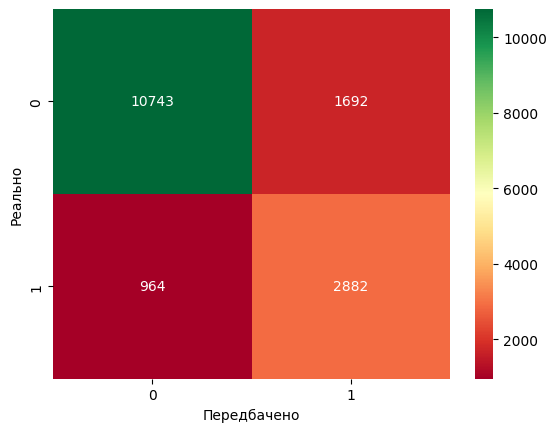

In [75]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено')
plt.ylabel('Реально')
plt.show()

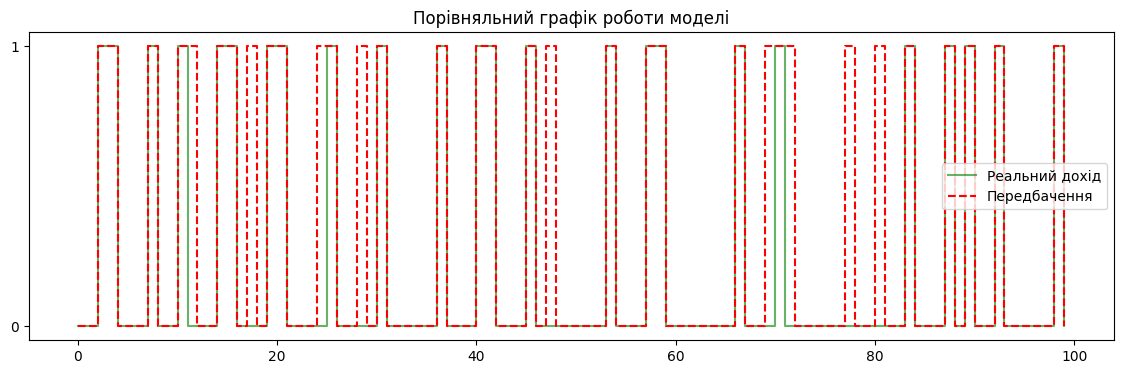

In [76]:
test = y_test.values[:100]
pred = y_pred[:100].flatten()

plt.figure(figsize=(14, 4))

plt.step(range(100), test, label='Реальний дохід', color='green', where='post', alpha=0.6)
plt.step(range(100), pred, label='Передбачення', color='red', linestyle='--', where='post')

plt.title('Порівняльний графік роботи моделі')
plt.yticks([0, 1], ['0', '1'])
plt.legend()
plt.show()